# Importing

In [67]:
# %% Cell 1: Imports
from doctest import OutputChecker

import pandas as pd
import numpy as np
from darts import TimeSeries
from darts.models import ARIMA, LinearRegressionModel, RandomForest, XGBModel

seed = 24775456

import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
import pyarrow as pa
import datetime as dt

# Load Data 

In [68]:
# %% Cell 2: Load Data
def loadData():
    df = pd.read_parquet("gafanha.parquet")
    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.round("h")
    print(df.count())
    return (
        df.pivot_table(index="timestamp", columns="collection", values="value", aggfunc="median")
        .asfreq("h")
        .loc[:"2024-12-31 23:00"]
        .reset_index()
    )

df = loadData()




# %% Cell 3: Readings per day per variable - for validating the dataset only
def checkDailyCount(df):
    df_daily_counts = df.set_index("timestamp").resample("D").count()

    # quick visual: counts per year for each variable
    df_daily_counts.groupby(df_daily_counts.index.year).mean().plot(
        kind="bar", figsize=(12, 5), title="Avg daily reading count per variable, by year"
    )
    plt.ylabel("avg readings/day")
    plt.tight_layout()
    plt.show()

station       916774
timestamp     916774
collection    916774
value         916774
unit          916774
source_db     916774
date          916774
values        916774
dtype: int64


In [69]:
# %% Cell 4: Force daily, median and fill in missing values with darts package
from darts.utils.missing_values import fill_missing_values
daily = df.set_index("timestamp").resample("D").median()
daily = daily.asfreq("D")

print(daily.count())


# Set up the AQI bins for each pollutant based on the standard AQI breakpoints (European standards)
aqi_bins = {
    "PM25": [-np.inf, 10, 20, 25, 50, np.inf],
    "PM10": [-np.inf, 20, 35, 50, 100, np.inf],
    "NO2":  [-np.inf, 40, 100, 200, 400, np.inf],
    "O3":   [-np.inf, 80, 120, 180, 240, np.inf],
    "SO2":  [-np.inf, 100, 200, 350, 500, np.inf],
}
sub_idx = pd.concat(
    [pd.cut(daily[p], bins=b, labels=[1, 2, 3, 4, 5]).astype(float) for p, b in aqi_bins.items()],
    axis=1,
)
daily["AQI"] = sub_idx.max(axis=1, skipna=True)
dominant = sub_idx.dropna(how="all").idxmax(axis=1)
last_valid = daily["AQI"].last_valid_index() 
print(last_valid)

# interpolates NaNs values
daily.index = daily.index.tz_localize(None)
series = TimeSeries.from_dataframe(daily, freq="D")
series = fill_missing_values(series)

collection
Benzene          2963
CO               3010
NO               2979
NO2              2979
NOx              2979
O3               3008
PM10             2632
PM25             2626
Particles        2626
Precipitation     366
Radiation         366
SO2              2990
Temperature      2635
WindDirection    3001
WindSpeed        3001
dtype: int64
2024-12-31 00:00:00+00:00


In [70]:
print(sub_idx.notna().groupby(sub_idx.index.year).mean())
dominant.groupby(dominant.index.year).value_counts(normalize=True).unstack()

               PM25      PM10       NO2        O3       SO2
timestamp                                                  
2016       1.000000  1.000000  1.000000  1.000000  1.000000
2017       1.000000  1.000000  0.997260  1.000000  1.000000
2018       0.835616  0.835616  0.819178  0.835616  0.832877
2019       1.000000  1.000000  0.994521  0.989041  0.975342
2020       0.972678  0.991803  0.948087  0.991803  0.991803
2021       0.980822  0.978082  1.000000  1.000000  1.000000
2022       1.000000  1.000000  0.994521  1.000000  0.986301
2023       0.983562  0.983562  0.983562  1.000000  0.986301
2024       0.000000  0.000000  1.000000  1.000000  0.994536


,NO2,O3,PM10,PM25
timestamp,,,,
2016,NaN,0.013072,0.346405,0.640523
2017,NaN,0.027397,0.405479,0.567123
2018,NaN,0.026230,0.767213,0.206557
2019,NaN,0.021918,0.536986,0.441096
2020,NaN,0.071429,0.109890,0.818681
2021,0.019178,0.082192,0.082192,0.816438
2022,NaN,0.032877,0.060274,0.906849
2023,0.005479,0.095890,0.041096,0.857534
2024,0.770492,0.229508,NaN,NaN


# Set up and prepare for training 3 XGBoost Models

In [73]:
# %% Cell 5: Set targets and covariates
target = series["AQI"]
covariates = series.drop_columns(["AQI"])

In [74]:
# %% Cell 6: generic per-period pipeline
import optuna
from darts.metrics import rmse, mae, mape

def run_period(target, covariates, model_cls, param_space, fixed_param, n_trials=500):

    # Split the data into training, validation, and test sets
    y_train, y_temp = target.split_before(0.6)
    y_val, y_test = y_temp.split_before(0.5)
    x_train, x_temp = covariates.split_before(0.6)
    x_val, x_test = x_temp.split_before(0.5)

    # Define the objective function for Optuna to find best parameters
    def findParam(trial):
        params = {name: fn(trial) for name, fn in param_space.items()}
        model = model_cls(**params, **fixed_param)
        model.fit(y_train, past_covariates=x_train)
        preds = model.historical_forecasts(
            series=y_train.append(y_val), past_covariates=x_train.append(x_val),
            start=y_val.start_time(), forecast_horizon=1, stride=1,
            retrain=False, last_points_only=True, verbose=False,
        ).map(lambda x: np.round(x))
        return rmse(y_val, preds), mae(y_val, preds), mape(y_val, preds)

    # Minimise all three metrics (RMSE, MAE, MAPE) simultaneously
    study = optuna.create_study(directions=["minimize"] * 3,
                                sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(findParam, n_trials=n_trials, show_progress_bar=True)

    vals = np.array([t.values for t in study.best_trials])
    best = study.best_trials[np.argmin((vals / vals.min(axis=0)).sum(axis=1))]

    y_fit, x_fit = y_train.append(y_val), x_train.append(x_val)
    test_pred = model_cls(**best.params, **fixed_param).historical_forecasts(
        series=y_fit.append(y_test), past_covariates=x_fit.append(x_test),
        start=y_test.start_time(), forecast_horizon=1, stride=1,
        retrain=True, train_length=None, last_points_only=True, verbose=False,
    ).map(lambda x: np.round(x))


    # naive = TimeSeries.from_times_and_values(
    #     y_test.time_index, target.to_series().shift(1).loc[y_test.time_index].values)

    # Fit the final model on the combined training and validation sets - for SHAP analysis and feature importance
    model = model_cls(**best.params, **fixed_param).fit(y_fit, past_covariates=x_fit)

    return dict(
        model=model, params=best.params, y=target, x=covariates, y_test=y_test, x_test=x_test, test_pred=test_pred,
        model_metrics=(rmse(y_test, test_pred), mae(y_test, test_pred), mape(y_test, test_pred)),
        # naive_metrics=(rmse(y_test, naive), mae(y_test, naive), mape(y_test, naive)),
        sizes=(len(y_train), len(y_val), len(y_test)),
    )

# For Each of the Periods

In [75]:
# %% Cell 7: XGBoost decalration, run all periods
from darts.models import XGBModel

xgb_fixed = dict(lags=7, lags_past_covariates=7, output_chunk_length=1,
                 tree_method="hist", n_jobs=-1, random_state=seed, objective="reg:absoluteerror")
xgb_space = dict(
    n_estimators=lambda t: t.suggest_int("n_estimators", 50, 400),
    max_depth=lambda t: t.suggest_int("max_depth", 3, 10),
    learning_rate=lambda t: t.suggest_float("learning_rate", 0.01, 0.3),
    subsample=lambda t: t.suggest_float("subsample", 0.5, 1.0),
    colsample_bytree=lambda t: t.suggest_float("colsample_bytree", 0.5, 1.0),
)

# Run the pipeline on 3 periods: pre, during, post
bounds = {"pre":    (None, "2020-02-29"),
          "during": ("2020-03-01", "2021-04-30"),
          "post":   ("2021-05-01", None)}

results = {}
for name, (s, e) in bounds.items():
    lo = pd.Timestamp(s) if s else target.start_time()
    hi = pd.Timestamp(e) if e else target.end_time()
    results[name] = run_period(target.slice(lo, hi), covariates.slice(lo, hi), XGBModel, xgb_space, xgb_fixed)
    r = results[name]
    print(name, r["sizes"], "model", r["model_metrics"]) #, "naive", r["naive_metrics"])
    r["model"].save(f"xgb_aqi_{name}.pkl")

[I 2026-09-29 09:39:04,000] A new study created in memory with name: no-name-50918dc8-3c6f-4041-99b9-2f895b9a2a41


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-09-29 09:39:04,581] Trial 0 finished with values: [0.8532111981561211, 0.5900383141762452, 24.016602809706256] and parameters: {'n_estimators': 305, 'max_depth': 5, 'learning_rate': 0.057767584076709344, 'subsample': 0.5009410674841044, 'colsample_bytree': 0.6640238236823508}.
[I 2026-09-29 09:39:04,970] Trial 1 finished with values: [0.816496580927726, 0.5670498084291188, 23.295019157088124] and parameters: {'n_estimators': 388, 'max_depth': 3, 'learning_rate': 0.03779387042291126, 'subsample': 0.7604974790163449, 'colsample_bytree': 0.6113560949566658}.
[I 2026-09-29 09:39:06,441] Trial 2 finished with values: [0.922266074754828, 0.6436781609195402, 25.24904214559387] and parameters: {'n_estimators': 302, 'max_depth': 9, 'learning_rate': 0.13045491059387773, 'subsample': 0.5825108547624366, 'colsample_bytree': 0.7279536692929418}.
[I 2026-09-29 09:39:07,109] Trial 3 finished with values: [0.909717652294684, 0.6283524904214559, 24.8786717752235] and parameters: {'n_estimators'

[I 2026-09-29 09:50:15,988] A new study created in memory with name: no-name-b865f873-879f-4682-9038-f9995e37d56f


pre (784, 261, 263) model (np.float64(0.8409663100271976), np.float64(0.5627376425855514), np.float64(37.47148288973384))


...

[I 2026-09-29 09:50:16,405] Trial 0 finished with values: [1.0232589230148017, 0.6235294117647059, 29.235294117647058] and parameters: {'n_estimators': 305, 'max_depth': 5, 'learning_rate': 0.057767584076709344, 'subsample': 0.5009410674841044, 'colsample_bytree': 0.6640238236823508}.
[I 2026-09-29 09:50:16,754] Trial 1 finished with values: [1.0627378626481143, 0.6588235294117647, 31.88235294117647] and parameters: {'n_estimators': 388, 'max_depth': 3, 'learning_rate': 0.03779387042291126, 'subsample': 0.7604974790163449, 'colsample_bytree': 0.6113560949566658}.
[I 2026-09-29 09:50:17,471] Trial 2 finished with values: [1.0516094108276022, 0.6823529411764706, 36.921568627450974] and parameters: {'n_estimators': 302, 'max_depth': 9, 'learning_rate': 0.13045491059387773, 'subsample': 0.5825108547624366, 'colsample_bytree': 0.7279536692929418}.
[I 2026-09-29 09:50:17,819] Trial 3 finished with values: [1.0516094108276022, 0.6588235294117647, 34.921568627450974] and parameters: {'n_estima

[I 2026-09-29 09:54:06,704] A new study created in memory with name: no-name-9e60ad2f-a02b-4aaf-a98c-0a97292e382e


during (255, 85, 86) model (np.float64(0.8892118276421005), np.float64(0.6046511627906976), np.float64(31.608527131782946))


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-09-29 09:54:07,216] Trial 0 finished with values: [0.7531030335249471, 0.5447761194029851, 49.81343283582089] and parameters: {'n_estimators': 305, 'max_depth': 5, 'learning_rate': 0.057767584076709344, 'subsample': 0.5009410674841044, 'colsample_bytree': 0.6640238236823508}.
[I 2026-09-29 09:54:07,570] Trial 1 finished with values: [0.7304670352262578, 0.5186567164179104, 47.699004975124375] and parameters: {'n_estimators': 388, 'max_depth': 3, 'learning_rate': 0.03779387042291126, 'subsample': 0.7604974790163449, 'colsample_bytree': 0.6113560949566658}.
[I 2026-09-29 09:54:08,663] Trial 2 finished with values: [0.7506216329289315, 0.5410447761194029, 49.937810945273625] and parameters: {'n_estimators': 302, 'max_depth': 9, 'learning_rate': 0.13045491059387773, 'subsample': 0.5825108547624366, 'colsample_bytree': 0.7279536692929418}.
[I 2026-09-29 09:54:09,224] Trial 3 finished with values: [0.7431277184778867, 0.5298507462686567, 46.76616915422885] and parameters: {'n_estimat

# Cross Validation between models

In [78]:
# %% Cell 8: cross-evaluation
def score(model, y_w):
    end = y_w.end_time()
    p = model.historical_forecasts(
        series=target.slice(target.start_time(), end),
        past_covariates=covariates.slice(covariates.start_time(), end),
        start=y_w.start_time(), forecast_horizon=1, stride=1,
        retrain=False, last_points_only=True, verbose=False,
    ).map(lambda x: np.round(x))
    return rmse(y_w, p), mae(y_w, p)

cross = pd.DataFrame(
    {test: {f"{m}-model": score(results[m]["model"], results[test]["y_test"])[0]
            for m in results}
     for test in results}
).round(3)
cross.index.name, cross.columns.name = "model", "test window (RMSE)"
print(cross)

test window (RMSE)    pre  during   post
model                                   
pre-model           0.865   0.921  0.888
during-model        0.931   0.946  0.695
post-model          0.850   0.889  0.395


# Testing Area

In [29]:
# %% Cell 8: sanity check, full dataset
for L in (7, 14):
    fixed_param.update(lags=L, lags_past_covariates=L)
    f = run_period(target, covariates, n_trials=50)
    print(f"{L}, {f['model_metrics']}, {f['naive_metrics']}")

[I 2026-09-28 22:36:57,754] A new study created in memory with name: no-name-6851d09f-5794-4bc5-a1c7-1cc912d7176a


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-09-28 22:36:58,472] Trial 0 finished with values: [0.8429526117707073, 0.551219512195122, 35.54471544715447] and parameters: {'n_estimators': 305, 'max_depth': 5, 'learning_rate': 0.057767584076709344, 'subsample': 0.5009410674841044, 'colsample_bytree': 0.6640238236823508}.
[I 2026-09-28 22:36:58,882] Trial 1 finished with values: [0.8332520285540449, 0.5382113821138211, 34.108401084010836] and parameters: {'n_estimators': 388, 'max_depth': 3, 'learning_rate': 0.03779387042291126, 'subsample': 0.7604974790163449, 'colsample_bytree': 0.6113560949566658}.
[I 2026-09-28 22:37:00,872] Trial 2 finished with values: [0.8806870931821137, 0.583739837398374, 38.476964769647694] and parameters: {'n_estimators': 302, 'max_depth': 9, 'learning_rate': 0.13045491059387773, 'subsample': 0.5825108547624366, 'colsample_bytree': 0.7279536692929418}.
[I 2026-09-28 22:37:01,868] Trial 3 finished with values: [0.8610826990679503, 0.5821138211382114, 39.83468834688347] and parameters: {'n_estimator

[I 2026-09-28 22:41:13,386] A new study created in memory with name: no-name-f6a613aa-1b18-4f9a-9ba3-621b9ff4cd06


7, (np.float64(0.4576194755641246), np.float64(0.20616883116883117), np.float64(15.909090909090908)), (np.float64(0.4450302776800114), np.float64(0.19480519480519481), np.float64(14.366883116883116))


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-09-28 22:41:14,485] Trial 0 finished with values: [0.8496771266264587, 0.5691056910569106, 36.72086720867208] and parameters: {'n_estimators': 305, 'max_depth': 5, 'learning_rate': 0.057767584076709344, 'subsample': 0.5009410674841044, 'colsample_bytree': 0.6640238236823508}.
[I 2026-09-28 22:41:15,042] Trial 1 finished with values: [0.8342271629176273, 0.5463414634146342, 34.94037940379403] and parameters: {'n_estimators': 388, 'max_depth': 3, 'learning_rate': 0.03779387042291126, 'subsample': 0.7604974790163449, 'colsample_bytree': 0.6113560949566658}.
[I 2026-09-28 22:41:18,713] Trial 2 finished with values: [0.8751306522666118, 0.616260162601626, 42.88075880758807] and parameters: {'n_estimators': 302, 'max_depth': 9, 'learning_rate': 0.13045491059387773, 'subsample': 0.5825108547624366, 'colsample_bytree': 0.7279536692929418}.
[I 2026-09-28 22:41:20,461] Trial 3 finished with values: [0.8806870931821137, 0.6, 40.36043360433604] and parameters: {'n_estimators': 131, 'max_de

# Report, SHAP and other analysis visualisation

In [84]:
# %% Cell 9: report
report = pd.DataFrame([
    dict(period=name, model=label, rmse=m[0], mae=m[1], mape=m[2], **dict(zip(("train", "val", "test"), r["sizes"])))
    for name, r in results.items()
    for label, m in (("xgb", r["model_metrics"]),) #, ("naive", r["naive_metrics"]))
])
params = pd.DataFrame({name: r["params"] for name, r in results.items()}).T

print(report.round(3).to_string(index=False))
print(params)
report.to_csv("report_metrics.csv", index=False)
params.to_csv("report_params.csv")

period model  rmse   mae   mape  train  val  test
   pre   xgb 0.841 0.563 37.471    784  261   263
during   xgb 0.889 0.605 31.609    255   85    86
  post   xgb 0.381 0.145 12.082    804  268   269
        n_estimators  max_depth  learning_rate  subsample  colsample_bytree
pre            387.0        5.0       0.032115   0.881677          0.975056
during         295.0        5.0       0.256180   0.794040          0.543480
post           111.0        3.0       0.083043   0.611879          0.548261


At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.
At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.
At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.
At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.
At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.


['AQI', 'Benzene', 'CO', 'NO', 'NO2', 'NOx', 'O3', 'PM10', 'PM25', 'Particles', 'Precipitation', 'Radiation', 'SO2', 'Temperature', 'WindDirection', 'WindSpeed']


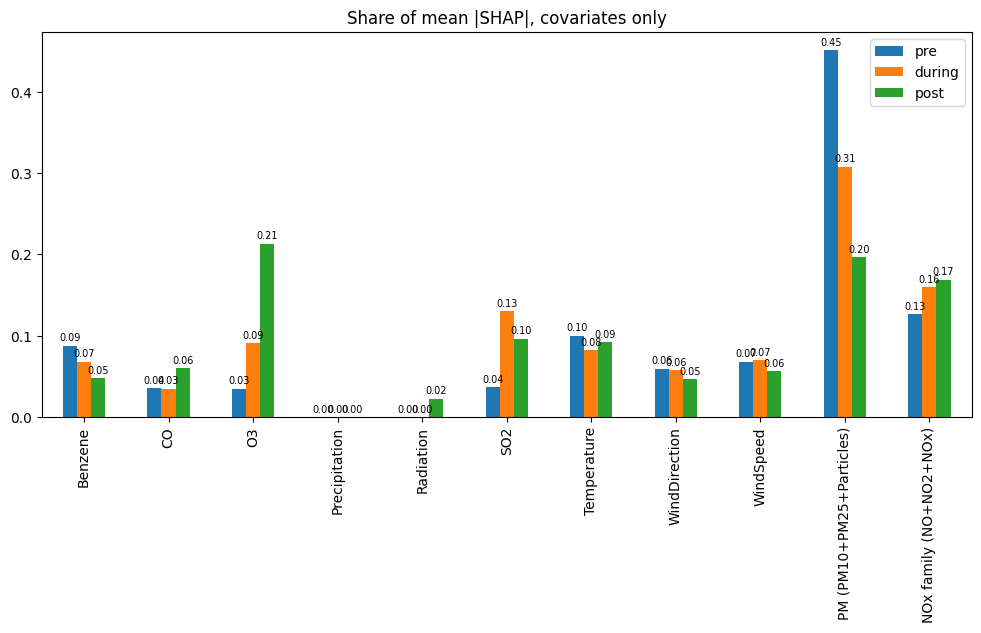

Currently Radiation and Prepicipitation are having no data until 2024 -> they are still included but this is a limitation of the dataset. The model is not able to learn from these variables and they are not contributing to the prediction.


In [86]:
# %% Cell 10: SHAP per period
import re
from darts.explainability import ShapExplainer
import warnings
warnings.filterwarnings("ignore")

def var_importance(r):
    res = ShapExplainer(r["model"]).explain(
        foreground_series=r["y"], foreground_past_covariates=r["x"])
    sv = res.get_explanation(horizon=1, component="AQI").to_dataframe()
    
    # mean |SHAP| on test days
    sv = sv.loc[r["y_test"].time_index].abs().mean()      
    return sv.groupby(lambda c: re.sub(r"_(target|pastcov)_lag-\d+$", "", c)).sum()

imp = pd.DataFrame({name: var_importance(r) for name, r in results.items()})

# check names match the regex
print(imp.index.tolist())      

# Grouping variables into families for better visualisation
groups = {"PM (PM10+PM25+Particles)": ["PM10", "PM25", "Particles"],
          "NOx family (NO+NO2+NOx)": ["NO", "NO2", "NOx"]}

def grouped(imp):
    g = imp.drop("AQI")
    for name, cols in groups.items():
        g.loc[name] = g.loc[cols].sum()
        g = g.drop(cols)
    return g / g.sum()

share = grouped(imp)
ax = share.plot.bar(figsize=(12, 5), title="Share of mean |SHAP|, covariates only")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.show()
print(f"Currently Radiation and Prepicipitation are having no data until 2024 -> they are still included but this is a limitation of the dataset. The model is not able to learn from these variables and they are not contributing to the prediction.")

# imp_cov = imp.drop("AQI")
# (imp_cov / imp_cov.sum()).plot.bar(figsize=(12, 5), title="Share of mean |SHAP|, covariates only")
# plt.show()

At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.


At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.
At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.
At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.
At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.


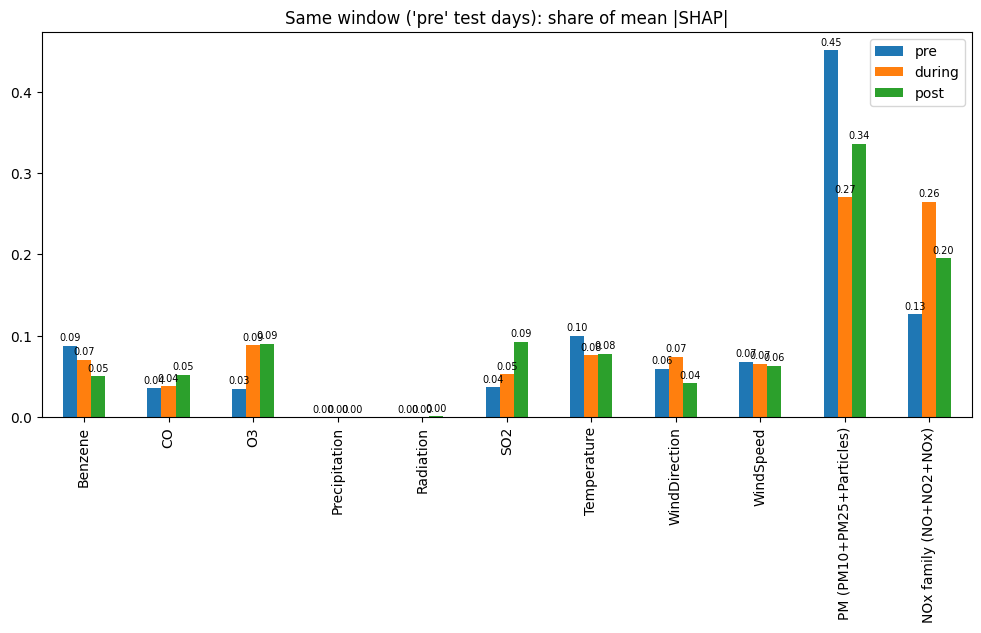

At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.
At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.


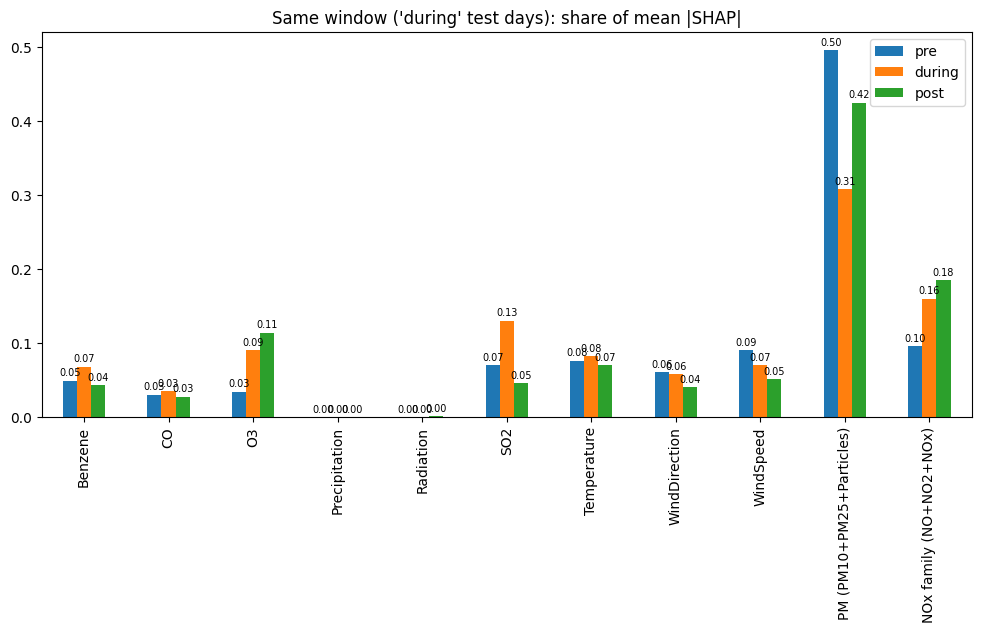

At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.
At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.
At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.
At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.
At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.


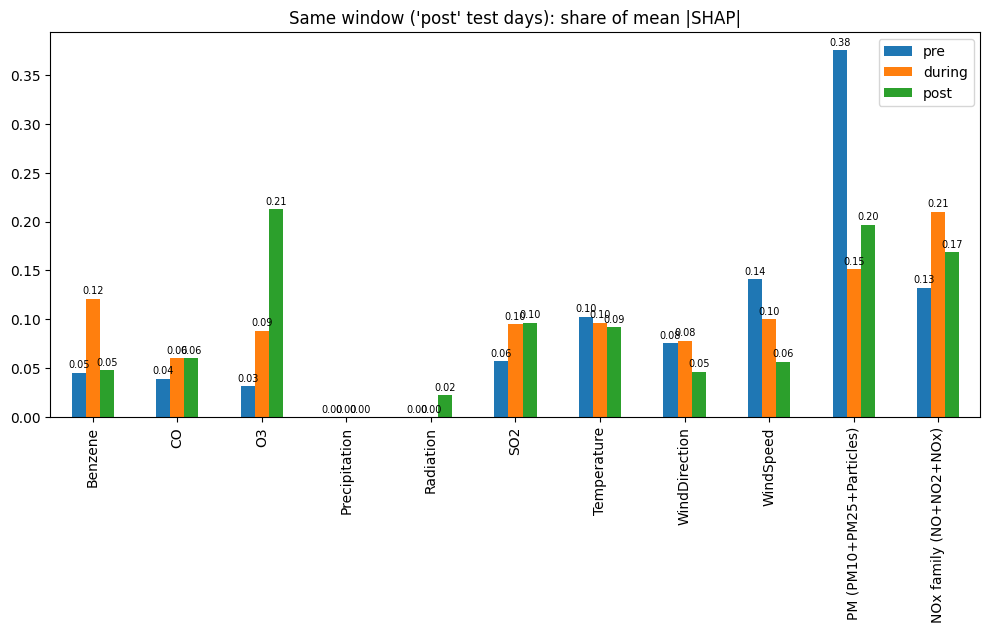

In [87]:
# %% Cell 12: SHAP, all 3 models on the same window
def var_importance_on(model, y_w, days=14):
    lo, hi = y_w.start_time() - pd.Timedelta(days=days), y_w.end_time()
    res = ShapExplainer(model).explain(
        foreground_series=target.slice(lo, hi),
        foreground_past_covariates=covariates.slice(lo, hi))
    sv = res.get_explanation(horizon=1, component="AQI").to_dataframe()
    sv = sv.loc[y_w.time_index].abs().mean()
    return sv.groupby(lambda c: re.sub(r"_(target|pastcov)_lag-\d+$", "", c)).sum()

# Currentlyt using the post period as the window for comparison, but can be changed to pre or during
y_w = results["pre"]["y_test"]
same = pd.DataFrame({m: var_importance_on(r["model"], y_w) for m, r in results.items()})
same_share = grouped(same)

ax = same_share.plot.bar(figsize=(12, 5),
    title=f"Same window ('{[k for k,v in results.items() if v['y_test'] is y_w][0]}' test days): share of mean |SHAP|")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.show()


y_w = results["during"]["y_test"]
same = pd.DataFrame({m: var_importance_on(r["model"], y_w) for m, r in results.items()})
same_share = grouped(same)

ax = same_share.plot.bar(figsize=(12, 5),
    title=f"Same window ('{[k for k,v in results.items() if v['y_test'] is y_w][0]}' test days): share of mean |SHAP|")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.show()


y_w = results["post"]["y_test"]
same = pd.DataFrame({m: var_importance_on(r["model"], y_w) for m, r in results.items()})
same_share = grouped(same)

ax = same_share.plot.bar(figsize=(12, 5),
    title=f"Same window ('{[k for k,v in results.items() if v['y_test'] is y_w][0]}' test days): share of mean |SHAP|")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.show()

At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.
At least component 'AQI' of target series at index 0 is not stationary. Beware of wrong interpretation of the chosen explainability.


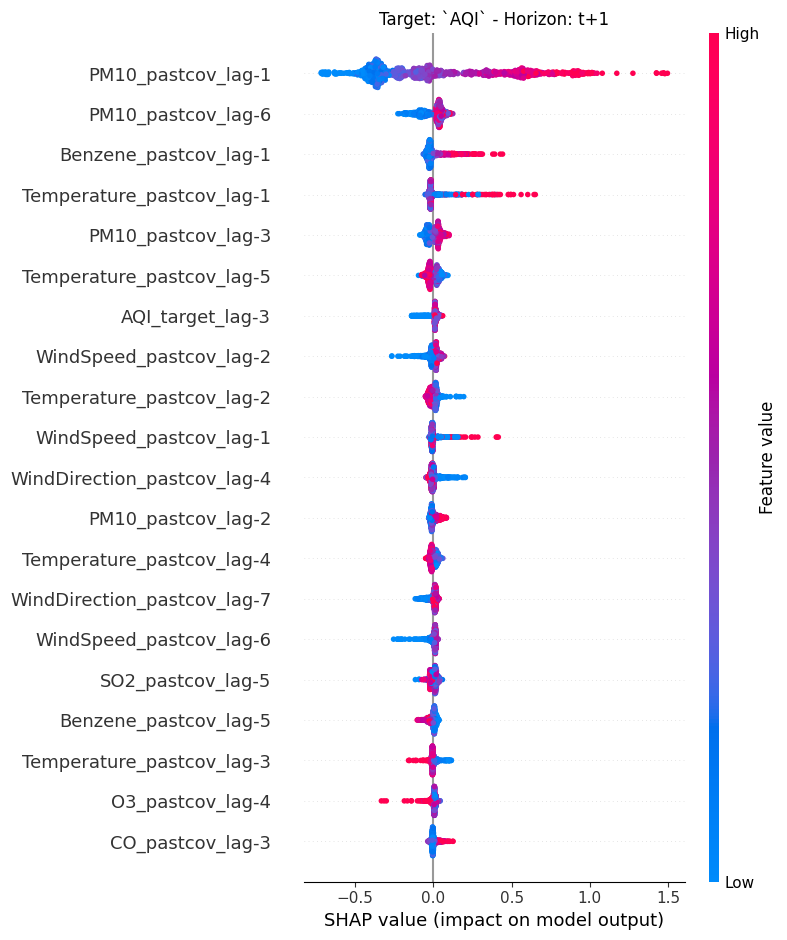

{1: {'AQI': .values =
  array([[ 6.74807117e-04, -1.87158410e-04,  9.08072747e-04, ...,
           5.60733676e-01,  2.30736844e-02, -8.46737064e-03],
         [ 2.85365526e-03,  1.81580166e-04,  8.81264918e-04, ...,
           4.95199949e-01, -2.77937157e-03, -8.94988514e-03],
         [ 6.81424653e-03,  7.98298628e-04,  8.71690107e-04, ...,
          -2.15903223e-02, -5.49318548e-03, -4.32947045e-03],
         ...,
         [ 3.65764543e-04, -3.08323739e-04,  7.28030922e-04, ...,
          -1.48187671e-02, -1.17804687e-02, -6.62039127e-03],
         [ 1.14784045e-04,  1.22383819e-04,  8.45183167e-05, ...,
          -1.70752686e-02, -6.14459626e-03, -6.24239398e-03],
         [ 3.31157731e-04,  1.16274008e-04,  2.40478502e-03, ...,
          -1.75586641e-02, -3.07996734e-03,  1.39121830e-01]],
        shape=(1039, 112), dtype=float32)
  
  .base_values =
  array([2.3285527, 2.3285527, 2.3285527, ..., 2.3285527, 2.3285527,
         2.3285527], shape=(1039,), dtype=float32)
  
  .data =


In [88]:
ShapExplainer(results["pre"]["model"]).summary_plot(horizons=1)

## Line graph for models' prediction vs actual data

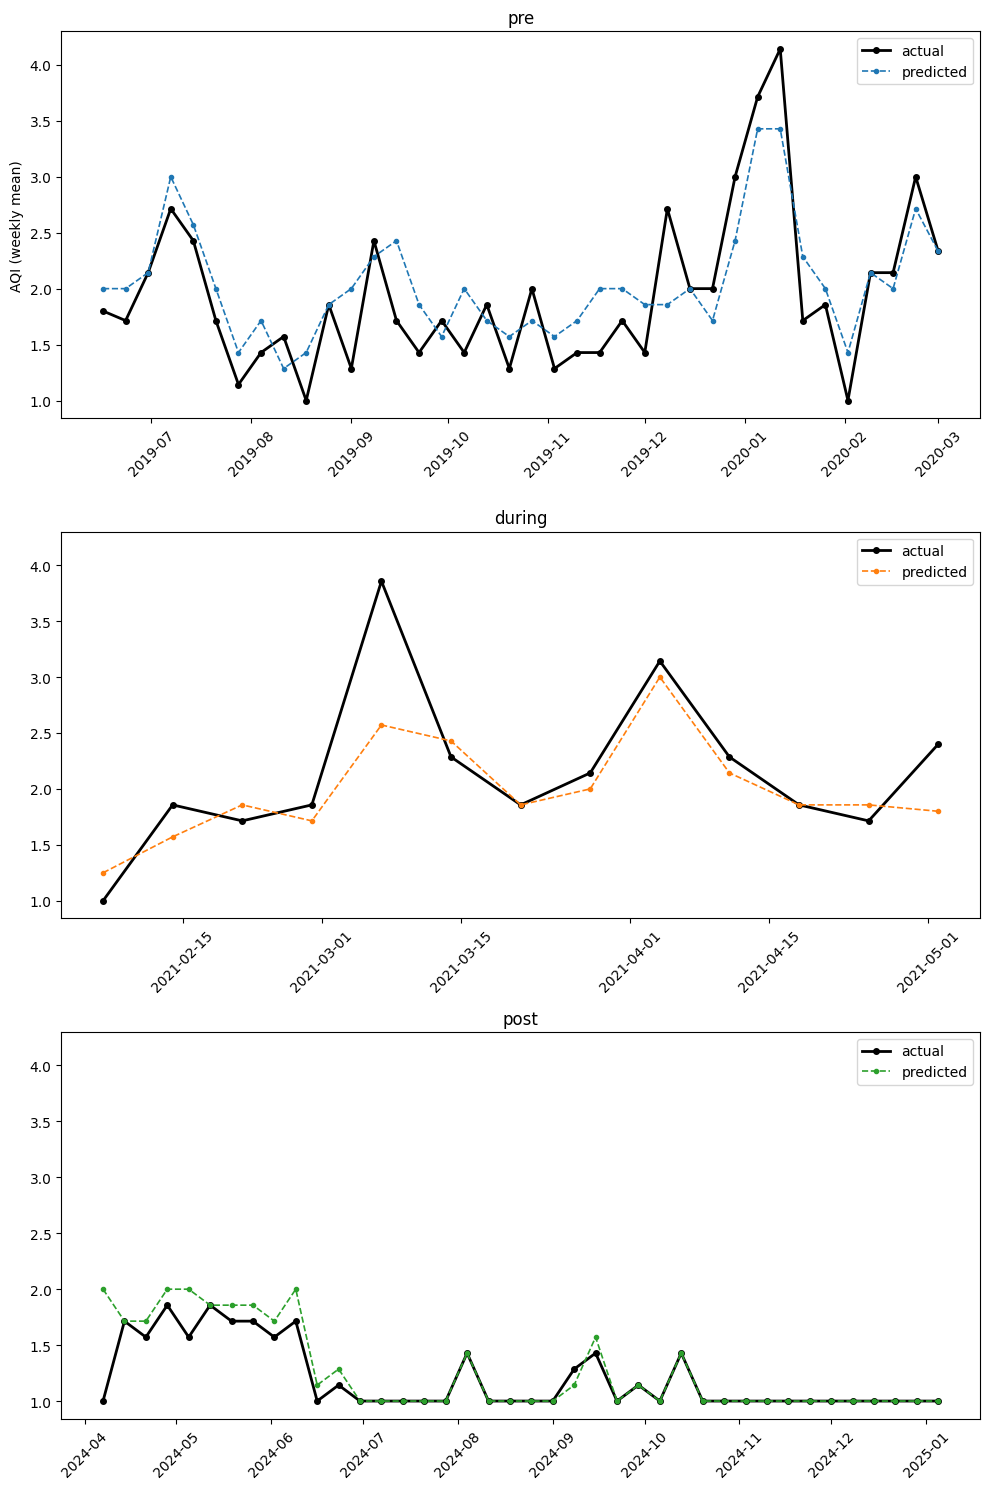

In [101]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharey=True)
colors = dict(pre="tab:blue", during="tab:orange", post="tab:green")

for ax, (name, r) in zip(axes, results.items()):
    actual_w = r["y_test"].to_series().resample("W").mean()
    pred_w = r["test_pred"].to_series().resample("W").mean()

    ax.plot(actual_w.index, actual_w.values, color="black", lw=2, marker="o", markersize=4, label="actual", zorder=2)
    ax.plot(pred_w.index, pred_w.values, color=colors[name], lw=1.2, marker="o", markersize=3,
        linestyle="--", label="predicted", zorder=3)
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

    

axes[0].set_ylabel("AQI (weekly mean)")
plt.tight_layout()
plt.show()